# LLM Quality Estimation with RAG
Comparing standard LLM translation vs RAG-enhanced translation using COMET Quality Estimation (Reference-Free) metrics.

### 1. Setting up the prototype and loading data:

#### WARNING: Open Ollama before running the whole Notebook

In [1]:
import logging

# Suppress httpx/httpcore logging
logging.getLogger("httpx").setLevel(logging.WARNING)
logging.getLogger("httpcore").setLevel(logging.WARNING)

import pandas as pd
import torch
import time
import os
import re
import ast
from tqdm.notebook import tqdm
from typing import Tuple, List

# LangChain & Chroma
from langchain_chroma import Chroma
from langchain_ollama import OllamaEmbeddings, OllamaLLM
from langchain_core.prompts import ChatPromptTemplate, SystemMessagePromptTemplate, HumanMessagePromptTemplate


# RAG Utils
from difflib import SequenceMatcher

# Evaluation (COMET QE)
from comet import download_model, load_from_checkpoint
import matplotlib.pyplot as plt

# Check GPU
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device: {torch.cuda.get_device_name(0)}")
    torch.set_float32_matmul_precision('high')


C:\Python_repositories\foreo-ai-engineering-project\.venv\Lib\site-packages\torchmetrics\utilities\imports.py:23: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


CUDA available: True
Device: NVIDIA GeForce RTX 4070 SUPER


In [2]:
# Configuration
MODELS = ["gemma2:9b", "gemma3:4b-it-qat", "thinkverse/towerinstruct:latest"]
TEMPERATURE = 0.3
RAG_PATH = "../rag"
DATA_PATH = "../data/en_corpus/en_corpus.csv"
OUTPUT_DIR = "../data/en_corpus/translations/"
os.makedirs(OUTPUT_DIR, exist_ok=True)


In [3]:
# Load Data
print(f"Loading data from {DATA_PATH}...")
df_base = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df_base)} segments.")
df_base.head()


Loading data from ../data/en_corpus/en_corpus.csv...
Loaded 839 segments.


,english,endpoint
0,This website uses cookies,peach-2-pro-max
1,"We use cookies to personalise content and ads,...",peach-2-pro-max
2,Necessary,peach-2-pro-max
3,Preferences,peach-2-pro-max
4,Statistics,peach-2-pro-max


### 2. Preparing the existing RAG vector database

In [4]:
# Initialize Vector DB
print(f"Initializing ChromaDB from {RAG_PATH}...")
embeddings = OllamaEmbeddings(model="nomic-embed-text")
vector_db = Chroma(
    persist_directory=RAG_PATH,
    embedding_function=embeddings,
    collection_name="foreo_translations"
)
print("Vector DB initialized.")


Initializing ChromaDB from ../rag...


Anonymized telemetry enabled. See                     https://docs.trychroma.com/telemetry for more information.


Vector DB initialized.


In [5]:
def clean_segment(text):
    if pd.isna(text):
        return ""
    text = str(text).strip()
    text = re.sub(r'\s+', ' ', text)
    return text

def retrieve_context(segment, k=5):
    results = vector_db.similarity_search(segment, k=k)
    context_pairs = []
    for d in results:
        src = d.page_content
        tgt = d.metadata.get("target", None)
        if tgt:
            context_pairs.append((src, tgt))
    return context_pairs

def best_match_score(segment, context_pairs):
    best_score = 0.0
    best_target = None
    for src, tgt in context_pairs:
        # We use SequenceMatcher for chunking before inference with RAG
        # https://dev.to/rajinh24/rag-chunking-strategies-that-actually-work-and-why-most-dont-49n2
        score = SequenceMatcher(None, segment.lower(), src.lower()).ratio()
        if score > best_score:
            best_score = score
            best_target = tgt
    return best_score, best_target


### 3. Creating and using the Language Model translation functions with and without RAG

In [6]:
def llm_translation(model_name, data, temp):
    system_template = (
        "You are a professional translator from English to Spanish from Spain. "
        "Translate the exact text provided by the user, regardless of its content or format. "
        "Also convert datetimes to the Spanish type dd/mm/yyyy."
        "Do not add any explanations, questions, or comments."
        "Do not translate product names."
        "Return only the final Spanish translation."
    )
    human_template = "{text}"
    
    llm = OllamaLLM(model=model_name, temperature=temp)
    prompt = ChatPromptTemplate.from_messages([
        SystemMessagePromptTemplate.from_template(system_template),
        HumanMessagePromptTemplate.from_template(human_template),
    ])
    chain = prompt | llm
    
    translations = []
    start_time = time.time()
    
    for text in tqdm(data["english"], desc=f"Standard: {model_name}"):
        if pd.isna(text) or not str(text).strip():
            translations.append("")
        else:
            try:
                res = chain.invoke({"text": text})
                translations.append(res)
            except Exception as e:
                translations.append(f"ERROR: {e}")
                
    elapsed = time.time() - start_time
    return translations, elapsed


In [7]:
def rag_translation_process(model_name, data, temp, similarity_threshold=0.92):
    llm = OllamaLLM(model=model_name, temperature=temp)
    
    translations = []
    start_time = time.time()
    
    for segment in tqdm(data["english"], desc=f"RAG: {model_name}"):
        if pd.isna(segment) or not str(segment).strip():
            translations.append("")
            continue
            
        # 1. Retrieve Context
        context_pairs = retrieve_context(segment, k=5)
        score, best_target = best_match_score(segment, context_pairs)
        
        # 2. Case A: Strong match -> Reuse
        if score >= similarity_threshold and best_target:
            translations.append(best_target)
            continue
            
        # 3. Case B: Weak match -> Few-shot prompt
        context_text = "\n".join([f"- Source: {src}\n  Target: {tgt}" for src, tgt in context_pairs])
        
        prompt = f"""
        You are a professional translator for the brand FOREO.
        Translate the text into Spanish, following the vocabulary, tone and wording style used in the examples.
        
        ### Style and Context Examples
        {context_text}
        
        ### Task
        Translate the following text to Spanish.
        Follow the style and terminology of the examples.
        Also convert datetime to the Spanish format dd/mm/yyyy.
        Do not translate product names.
        Do NOT add explanations, questions, or comments.
        Do NOT add any quotation marks or extra characters such as in ''MASCARAS PARA MANOS''', just translate it as it is if they are not present (e.g.: HAND MASKS -> MASCARILLAS DE MANO).
        Return only the translation.
        
        Text to translate:
        '''{segment}'''
        """
        
        try:
            res = llm.invoke(prompt).strip()
            translations.append(res)
        except Exception as e:
            translations.append(f"ERROR: {e}")
            
    elapsed = time.time() - start_time
    return translations, elapsed


In [9]:
results_df = df_base.copy()
elapsed_times = {}

for model in MODELS:
    # Standard
    print(f"Running Standard Translation for {model}...")
    std_trans, std_time = llm_translation(model, df_base, TEMPERATURE)
    col_std = f"{model}_std"
    results_df[col_std] = [clean_segment(t) for t in std_trans]
    elapsed_times[col_std] = std_time
    print(f"Standard Translation for {model}: {std_time:.2f} seconds\n")
    
    # RAG
    print(f"Running RAG Translation for {model}...")
    rag_trans, rag_time = rag_translation_process(model, df_base, TEMPERATURE)
    col_rag = f"{model}_rag"
    results_df[col_rag] = [clean_segment(t) for t in rag_trans]
    elapsed_times[col_rag] = rag_time
    print(f"RAG Translation for {model}: {rag_time:.2f} seconds\n")

# Save Translations
output_file = os.path.join(OUTPUT_DIR, "rag_test_translations.csv")
results_df.to_csv(output_file, index=False)
print(f"Saved translations to {output_file}")

# Save Times
time_file = os.path.join(OUTPUT_DIR, "rag_test_times.csv")
pd.DataFrame([elapsed_times]).to_csv(time_file, index=False)
print(f"Saved times to {time_file}")


Running Standard Translation for gemma2:9b...


Standard: gemma2:9b:   0%|          | 0/839 [00:00<?, ?it/s]

Standard Translation for gemma2:9b: 400.35 seconds

Running RAG Translation for gemma2:9b...


RAG: gemma2:9b:   0%|          | 0/839 [00:00<?, ?it/s]

RAG Translation for gemma2:9b: 337.15 seconds

Running Standard Translation for gemma3:4b-it-qat...


...

RAG Translation for gemma3:4b-it-qat: 379.41 seconds

Running Standard Translation for thinkverse/towerinstruct:latest...


Standard: thinkverse/towerinstruct:latest:   0%|          | 0/839 [00:00<?, ?it/s]

Standard Translation for thinkverse/towerinstruct:latest: 330.65 seconds

Running RAG Translation for thinkverse/towerinstruct:latest...


RAG: thinkverse/towerinstruct:latest:   0%|          | 0/839 [00:00<?, ?it/s]

RAG Translation for thinkverse/towerinstruct:latest: 260.32 seconds

Saved translations to ../data/en_corpus/translations/rag_test_translations.csv
Saved times to ../data/en_corpus/translations/rag_test_times.csv


### 4. Loading the Quality Estimation model and applying it to the results

In [28]:
# Load COMET QE Model
print("Loading COMET QE model (Unbabel/wmt20-comet-qe-da)...")
try:
    qe_model_path = download_model("Unbabel/wmt20-comet-qe-da")
    qe_model = load_from_checkpoint(qe_model_path)
    print("Model loaded successfully.")
except Exception as e:
    print(f"Error loading model: {e}")


def compute_qe_segment_scores(df, model_col):
    sources = df["english"].tolist()
    preds = df[model_col].tolist()

    data = [{"src": str(s), "mt": str(m)} for s, m in zip(sources, preds)]

    model_output = qe_model.predict(
        data,
        batch_size=8,
        gpus=1 if torch.cuda.is_available() else 0
    )

    return model_output.scores  # lista de scores por segmento

Loading COMET QE model (Unbabel/wmt20-comet-qe-da)...


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Encoder model frozen.


Model loaded successfully.


In [29]:
metrics_data = []
segment_scores = {}  # scores por segmento, por columna

model_cols = [c for c in results_df.columns if c not in ["english", "endpoint"]]

for col in model_cols:
    print(f"Evaluating {col}...")

    scores = compute_qe_segment_scores(results_df, col)

    # 👉 media (SYSTEM SCORE) para el gráfico
    system_score = round(sum(scores) / len(scores), 4)

    # 👉 guardamos scores individuales
    segment_scores[col] = scores

    # Parse model name and type
    if "_rag" in col:
        m_name = col.replace("_rag", "")
        m_type = "RAG"
    else:
        m_name = col.replace("_std", "")
        m_type = "Standard"

    metrics_data.append({
        "Model": m_name,
        "Type": m_type,
        "COMET QE": system_score,
        "Latency": elapsed_times.get(col, 0)
    })

metrics_df = pd.DataFrame(metrics_data)
metrics_file = os.path.join(OUTPUT_DIR, "rag_test_metrics.csv")
metrics_df.to_csv(metrics_file, index=False)

print(metrics_df)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


Evaluating gemma2:9b_std...


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Predicting DataLoader 0: 100%|██████████| 105/105 [00:02<00:00, 40.28it/s]
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Evaluating gemma2:9b_rag...


Predicting DataLoader 0: 100%|██████████| 105/105 [00:02<00:00, 40.92it/s]
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


...

Evaluating thinkverse/towerinstruct:latest_std...


Predicting DataLoader 0: 100%|██████████| 105/105 [00:03<00:00, 34.85it/s]
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Evaluating thinkverse/towerinstruct:latest_rag...


Predicting DataLoader 0: 100%|██████████| 105/105 [00:02<00:00, 39.73it/s]


                             Model      Type  COMET QE     Latency
0                        gemma2:9b  Standard    0.2868  400.349086
1                        gemma2:9b       RAG    0.3338  337.151873
2                 gemma3:4b-it-qat  Standard    0.3078  291.607665
3                 gemma3:4b-it-qat       RAG    0.3464  379.413727
4  thinkverse/towerinstruct:latest  Standard    0.2151  330.654522
5  thinkverse/towerinstruct:latest       RAG    0.2452  260.324405


#### Storing CSVs with individual COMET QE values per model and per segment:

In [30]:
from collections import defaultdict

def safe_filename(name: str) -> str:
    """
    Convierte nombres de modelo en nombres seguros para archivos.
    Ej: 'gemma2:9b' -> 'gemma2_9b'
    """
    return re.sub(r"[^\w\-_.]", "_", name)

SCORED_OUTPUT_DIR = "../data/en_corpus/scored_translations"
os.makedirs(SCORED_OUTPUT_DIR, exist_ok=True)

models = defaultdict(dict)

# Detectar columnas STD / RAG por modelo
for col in segment_scores.keys():
    if col.endswith("_std"):
        models[col.replace("_std", "")]["std"] = col
    elif col.endswith("_rag"):
        models[col.replace("_rag", "")]["rag"] = col

# Crear un CSV por modelo
for model_name, cols in models.items():
    print(f"Saving scored translations for model: {model_name}")

    df_out = pd.DataFrame()
    df_out["english"] = results_df["english"]

    if "std" in cols:
        std_col = cols["std"]
        df_out[f"{model_name}_std"] = results_df[std_col]
        df_out[f"{model_name}_std_scores"] = segment_scores[std_col]

    if "rag" in cols:
        rag_col = cols["rag"]
        df_out[f"{model_name}_rag"] = results_df[rag_col]
        df_out[f"{model_name}_rag_scores"] = segment_scores[rag_col]

    safe_name = safe_filename(model_name)

    output_path = os.path.join(
        SCORED_OUTPUT_DIR,
        f"{safe_name}_qe_scored.csv"
    )

    df_out.to_csv(output_path, index=False)
    print(f"Saved → {output_path}")


Saving scored translations for model: gemma2:9b
Saved → ../data/en_corpus/scored_translations\gemma2_9b_qe_scored.csv
Saving scored translations for model: gemma3:4b-it-qat
Saved → ../data/en_corpus/scored_translations\gemma3_4b-it-qat_qe_scored.csv
Saving scored translations for model: thinkverse/towerinstruct:latest
Saved → ../data/en_corpus/scored_translations\thinkverse_towerinstruct_latest_qe_scored.csv


### 5. Plotting the benchmarks of the scores and elapsed times

In [29]:
# Plotting
def plot_metric(df, metric, title):
    pivot = df.pivot(index="Model", columns="Type", values=metric)
    ax = pivot.plot(kind="bar", figsize=(10, 6), rot=45)

    # Title + labels
    plt.title(title)
    plt.ylabel(metric)

    # Grid
    ax.grid(True, axis="y", linestyle="--", alpha=0.6)

    # Set Y-axis limits depending on metric
    m = metric.upper()
    if "COMET" in m:
        # COMET scores are usually between 0 and 1 (or -1 to 1, but usually positive for good translations)
        # Adjust if needed based on observed range
        pass 
    elif m == "LATENCY":
        # Auto scale
        pass

    # Add value annotations above bars
    for container in ax.containers:
        if "COMET" in m:
            fmt = "%.3f"
        else:
            fmt = "%.2f"  # Latency
        ax.bar_label(container, fmt=fmt, padding=3)

    # Legend outside on the right
    ax.legend(title="Type", bbox_to_anchor=(1.02, 1), loc="upper left")

    plt.tight_layout()
    plt.show()


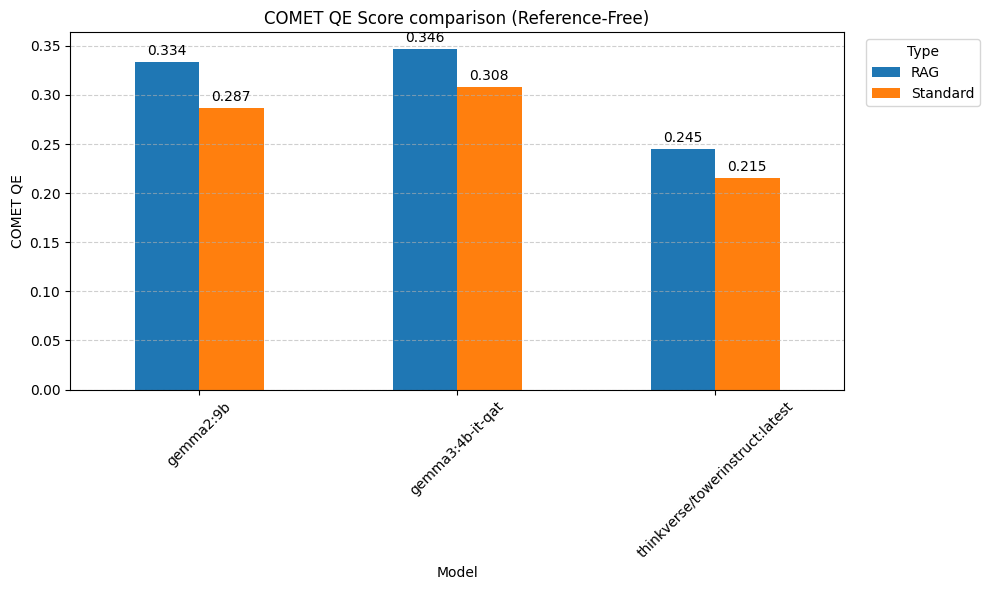

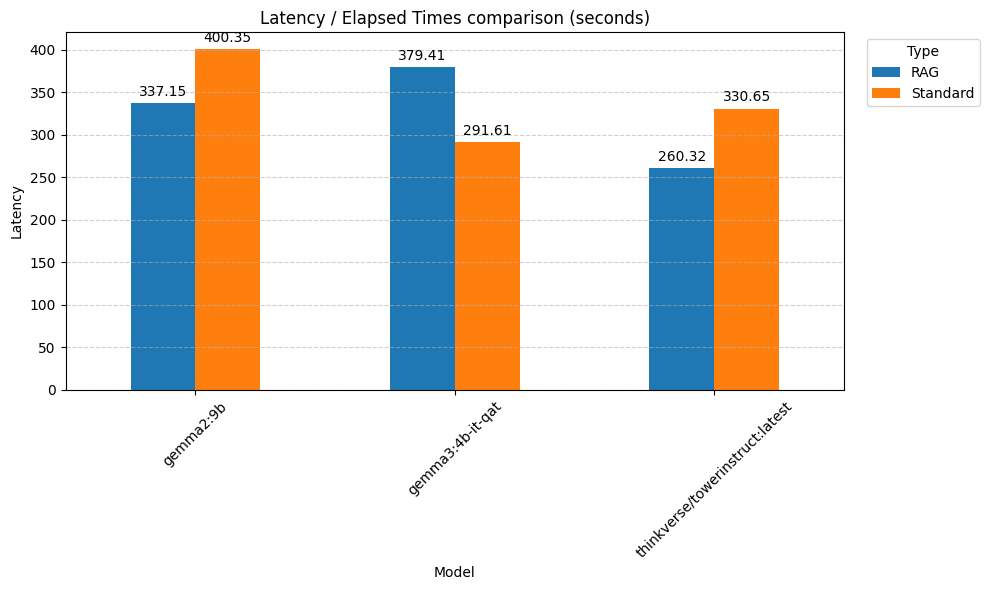

In [32]:
plot_metric(metrics_df, "COMET QE", "COMET QE Score comparison (Reference-Free)")
plot_metric(metrics_df, "Latency", "Latency / Elapsed Times comparison (seconds)")


In [22]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

In [23]:
scores_data = pd.read_csv("../data/en_corpus/scored_translations/gemma3_4b-it-qat_qe_scored.csv")
scores_data.head(5)

,english,gemma3:4b-it-qat_std,gemma3:4b-it-qat_rag,gemma3:4b-it-qat_std_scores,gemma3:4b-it-qat_rag_scores
0,This website uses cookies,Este sitio web utiliza cookies,Esta página web usa cookies,0.940141,0.881252
1,"We use cookies to personalise content and ads,...",Utilizamos cookies para personalizar el conten...,Las cookies de este sitio web se usan para per...,0.575372,0.546819
2,Necessary,Necesario,Necesario,0.522966,0.522966
3,Preferences,Preferencias,Preferencias,0.534235,0.534235
4,Statistics,Estadísticas,Estadística,0.657619,0.353435


In [24]:
scores_data_num = scores_data.select_dtypes(include=['int64', 'float64'])

In [25]:
scores_data_num

,gemma3:4b-it-qat_std_scores,gemma3:4b-it-qat_rag_scores
0,0.940141,0.881252
1,0.575372,0.546819
2,0.522966,0.522966
3,0.534235,0.534235
4,0.657619,0.353435
...,...,...
834,0.225639,0.225639
835,0.423826,0.407441
836,0.281956,0.281956
837,0.302138,-0.286862


In [26]:
scores_data_scaled = pd.DataFrame(
    scaler.fit_transform(scores_data_num),
    columns=scores_data_num.columns,
    index=scores_data_num.index
)

In [27]:
scores_data_scaled

,gemma3:4b-it-qat_std_scores,gemma3:4b-it-qat_rag_scores
0,0.917696,0.895204
1,0.754046,0.750585
2,0.730535,0.740270
3,0.735591,0.745143
4,0.790946,0.666959
...,...,...
834,0.597142,0.611696
835,0.686057,0.690313
836,0.622409,0.636050
837,0.631463,0.390075


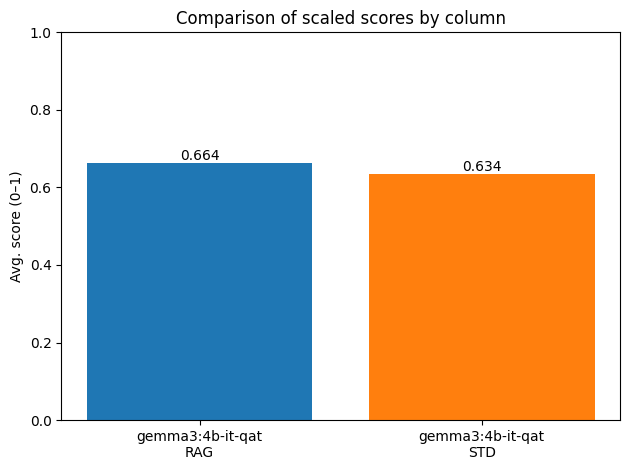

In [39]:
from matplotlib import rcParams

cols = ["gemma3:4b-it-qat_rag_scores", "gemma3:4b-it-qat_std_scores"]

values = scores_data_scaled[cols].mean()

colors = rcParams["axes.prop_cycle"].by_key()["color"]

plt.figure()

bars = plt.bar(
    values.index,
    values.values,
    color=colors[:len(values)]
)

plt.ylim(0, 1)
plt.ylabel("Avg. score (0–1)")
plt.title("Comparison of scaled scores by column")

xtick_labels = [
    "gemma3:4b-it-qat\nRAG",
    "gemma3:4b-it-qat\nSTD"
]
plt.xticks(range(len(values)), xtick_labels)

# Value on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.3f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()